t# Document length distributions

Plots per-document token-length distributions produced by `attn_bench/data_processing/dataset_doc_stats.py`.

On the cluster:
```bash
python attn_bench/data_processing/dataset_doc_stats.py
```
which writes one `<dataset_name>.npy` per dataset under `/users/$USER/store/datasets/analysis/doc-lengths`.
Transfer those `.npy` files locally and point `DATA_DIR` below at them.

In [16]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Local dir holding the transferred <dataset_name>.npy files
DATA_DIR = Path("../results/datasets/analysis/doc-lengths")

# Pretty names for the legend / titles (falls back to the file stem if not listed)
DISPLAY_NAMES = {
    "fineweb-edu-dedup-160B-datatrove": "fineweb-edu-full",
    "fineweb-edu-dedup-160B-datatrove_0.25": "fineweb-edu-0.25",
    "gutenberg_rep_1_256": "gutenberg",
}
def disp(name):
    return DISPLAY_NAMES.get(name, name)

PERCENTILES = [1, 5, 25, 50, 75, 90, 95, 99]

datasets = {p.stem: np.load(p) for p in sorted(DATA_DIR.glob("*.npy"))}
print("loaded:", list(datasets))

loaded: ['fineweb-edu-dedup-160B-datatrove', 'fineweb-edu-dedup-160B-datatrove_0.25', 'gutenberg_rep_1_256']


In [17]:
def print_stats(name, lengths):
    pct = np.percentile(lengths, PERCENTILES)
    print(f"### {disp(name)} ###")
    print(f"  documents:    {len(lengths):,}")
    print(f"  total tokens: {int(lengths.sum()):,}")
    print(f"  mean:         {lengths.mean():,.1f}")
    print(f"  std:          {lengths.std():,.1f}")
    print(f"  min / max:    {lengths.min():,} / {lengths.max():,}")
    print("  percentiles:  " + "  ".join(f"p{p}={int(v):,}" for p, v in zip(PERCENTILES, pct)))

for name, lengths in datasets.items():
    print_stats(name, lengths)

### fineweb-edu-full ###
  documents:    161,370,257
  total tokens: 160,159,943,902
  mean:         992.5
  std:          1,873.0
  min / max:    29 / 266,969
  percentiles:  p1=97  p5=149  p25=326  p50=607  p75=1,070  p90=1,868  p95=2,824  p99=7,358
### fineweb-edu-0.25 ###
  documents:    40,342,565
  total tokens: 40,038,865,413
  mean:         992.5
  std:          1,873.7
  min / max:    34 / 196,868
  percentiles:  p1=97  p5=149  p25=326  p50=607  p75=1,071  p90=1,868  p95=2,823  p99=7,348
### gutenberg ###
  documents:    337,260
  total tokens: 2,762,833,920
  mean:         8,192.0
  std:          0.0
  min / max:    8,192 / 8,192
  percentiles:  p1=8,192  p5=8,192  p25=8,192  p50=8,192  p75=8,192  p90=8,192  p95=8,192  p99=8,192


## Per-dataset histograms

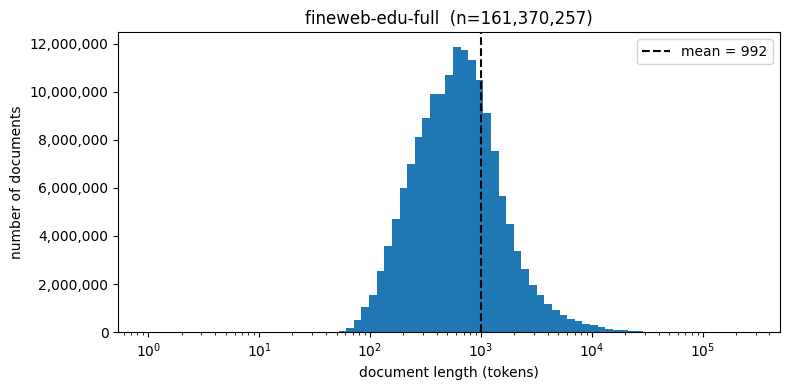

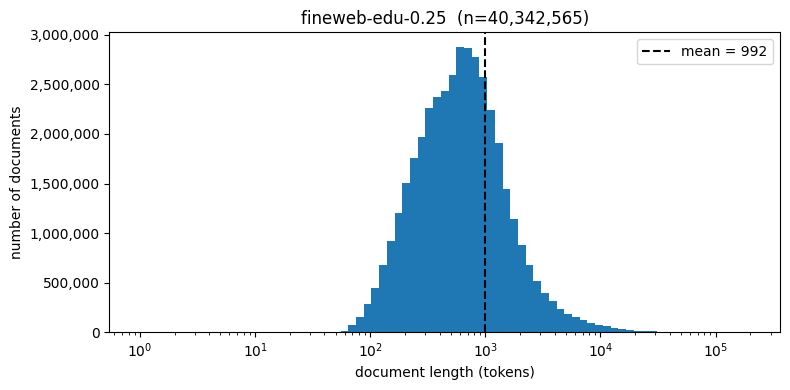

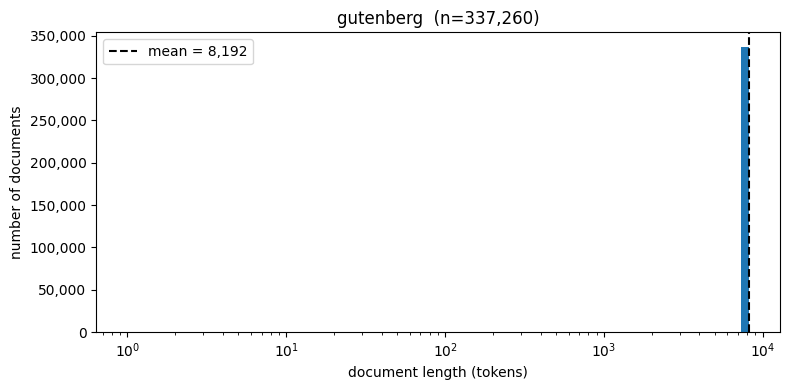

In [18]:
from matplotlib.ticker import FuncFormatter

thousands = FuncFormatter(lambda x, _: f"{int(x):,}")

for name, lengths in datasets.items():
    bins = np.logspace(0, np.log10(lengths.max() + 1), 80)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(lengths, bins=bins)
    ax.axvline(lengths.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean = {lengths.mean():,.0f}")
    ax.set_xscale("log")
    ax.yaxis.set_major_formatter(thousands)
    ax.set_xlabel("document length (tokens)")
    ax.set_ylabel("number of documents")
    ax.set_title(f"{disp(name)}  (n={len(lengths):,})")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Overlaid

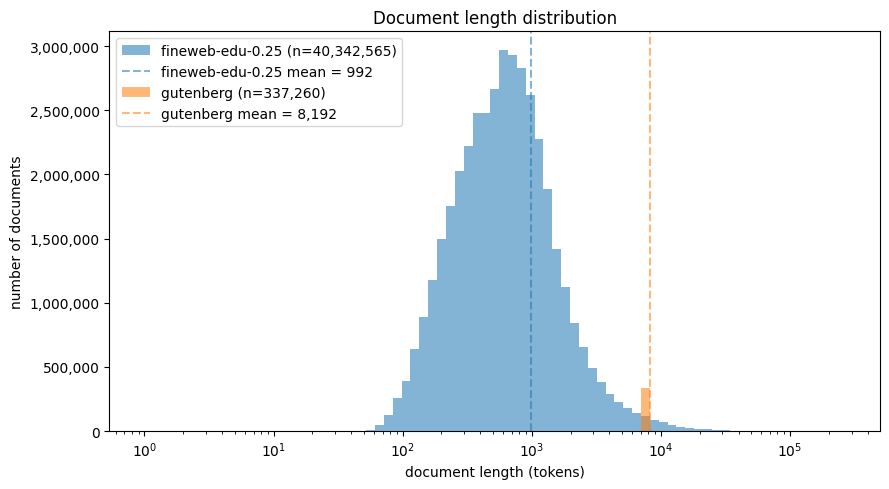

In [24]:
global_max = max(l.max() for l in datasets.values())
bins = np.logspace(0, np.log10(global_max + 1), 80)

fig, ax = plt.subplots(figsize=(9, 5))
for name, lengths in datasets.items():
    if name == "fineweb-edu-dedup-160B-datatrove":
        continue
    _, _, patches = ax.hist(lengths, bins=bins, alpha=0.55, label=f"{disp(name)} (n={len(lengths):,})")
    color = patches[0].get_facecolor()
    ax.axvline(lengths.mean(), color=color, linestyle="--", linewidth=1.5,
               label=f"{disp(name)} mean = {lengths.mean():,.0f}")
ax.set_xscale("log")
ax.yaxis.set_major_formatter(thousands)
ax.set_xlabel("document length (tokens)")
ax.set_ylabel("number of documents")
ax.set_title("Document length distribution")
ax.legend()
plt.tight_layout()
plt.show()